In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from utils.mapping import SERIES_NAME_MAPPING
from utils.plotTools import saving_manager

In [33]:
experiment_id = 'No_ITAlert'
## importing simulation results
results_dir = r'..\results'
plot_dir = fr'..\plots\{experiment_id}'

In [34]:
all_data_temporal = []
all_data_simulation = []
all_data_volcanic = []

for folder_name in os.listdir(results_dir):
    folder_path = os.path.join(results_dir, folder_name)

    run_id = folder_name

    file_temporal = os.path.join(folder_path, 'temporal_series_recorder.csv')
    file_simulation = os.path.join(folder_path, 'simulation_recorder.csv')
    file_volcanic = os.path.join(folder_path, 'volcanic_recorder.csv')

    if os.path.exists(file_temporal):
        df_temporal = pd.read_csv(file_temporal)
        df_temporal['run_id'] = run_id
        all_data_temporal.append(df_temporal)

        df_simulation = pd.read_csv(file_simulation)
        df_simulation['run_id'] = run_id
        all_data_simulation.append(df_simulation)

        df_volcanic = pd.read_csv(file_volcanic)
        df_volcanic['run_id'] = run_id
        all_data_volcanic.append(df_volcanic)

temporal_df = pd.concat(all_data_temporal,ignore_index=True)
simulation_df = pd.concat(all_data_simulation, ignore_index=True)
volcanic_df = pd.concat(all_data_volcanic, ignore_index=True)

In [35]:
## processing temporal dataframe to be more human-readable
with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(temporal_df)

# TODO: add all correct columns and think about emotion values which are trickier
columns_to_process = ['nb_people_warned', 'nb_people_prepared']
for column_name in columns_to_process:
    temporal_df[column_name] = temporal_df['nb_evacuated_people'] + temporal_df[column_name]

with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(temporal_df)

         time  nb_humans_on_island  nb_people_on_island  nb_LEAs_on_island  nb_humans_on_board  nb_people_on_board  nb_LEAs_on_board  nb_evacuated_humans  nb_evacuated_people  nb_evacuated_LEAs  nb_people_warned  nb_people_prepared  nb_people_going_to_port  nb_people_rescuing_others  nb_people_waiting  nb_people_at_port  nb_people_who_left_the_island  nb_joyous_people  nb_fearful_people  nb_alright_people               run_id
0         0.0                   70                   50                 20                   0                   0                 0                    0                    0                  0                 0                   0                        0                          0                  0                  0                              0                 0                  0                  0                  1.0
1        15.0                   70                   50                 20                   0                   0                 0        

In [36]:
with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(simulation_df)
    print('-'*115)

with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(volcanic_df.head())

    event_time                                    event_name                                              notes               run_id
0            0                      Volcanic Activity Update     Volcano LaFossawent from activity level 1 to 2                  1.0
1            0     Population Evacuation Order - LEAs issued  Civil defense ordered LEAs to issue evacuation...                  1.0
2           59                       Backups Reached Vulcano  20 backup LEAs arrived on the Island. Ordered ...                  1.0
3           59     Population Evacuation Order - LEAs issued  Civil defense ordered LEAs to issue evacuation...                  1.0
4         5597  Population Evacuation Order - LEAs fulfilled  The evacuation order of civil population issui...                  1.0
5         5625                         LEAs Evacuation Order  Civil defense ordered evacuation of Law Enforc...                  1.0
6         9346                    Civil Evacuation Completed  The eva

In [37]:
series_color = {
    "nb_humans_on_island": "#A52A2A",
    "nb_people_on_island": "#D2691E",
    "nb_LEAs_on_island": "#A0522D",
    "nb_humans_on_board": "#000080",
    "nb_people_on_board": "#4682B4",
    "nb_LEAs_on_board": "#87CEEB",
    "nb_evacuated_humans": "#006400",
    "nb_evacuated_people": "#228B22",
    "nb_evacuated_LEAs": "#3CB371",
    "nb_people_warned": "#ff7f0e",
    "nb_people_prepared": "#ffbb78",
    "nb_people_going_to_port": "#d62728",
    "nb_people_rescuing_others": "#e377c2",
    "nb_people_waiting": "#c7c7c7",
    "nb_people_at_port": "#bcbd22",
    "nb_people_who_left_the_island": "#dbdb8d",
    "nb_joyous_people": "#b4e05b",
    "nb_fearful_people": "#ff0000",
    "nb_alright_people": "#008080",
}

end_of_run_color = 'r'

In [38]:
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2
plt.rcParams['xtick.minor.size'] = 2
plt.rcParams['xtick.minor.width'] = 1.2
plt.rcParams['ytick.minor.size'] = 2
plt.rcParams['ytick.minor.width'] = 1.2
plt.rcParams['axes.linewidth'] = 1.2

# plt.rcParams['font.family'] = 'Trebuchet MS' # set the font family style
# plt.rcParams['pdf.fonttype'] = 42

## Multiple Line Plots

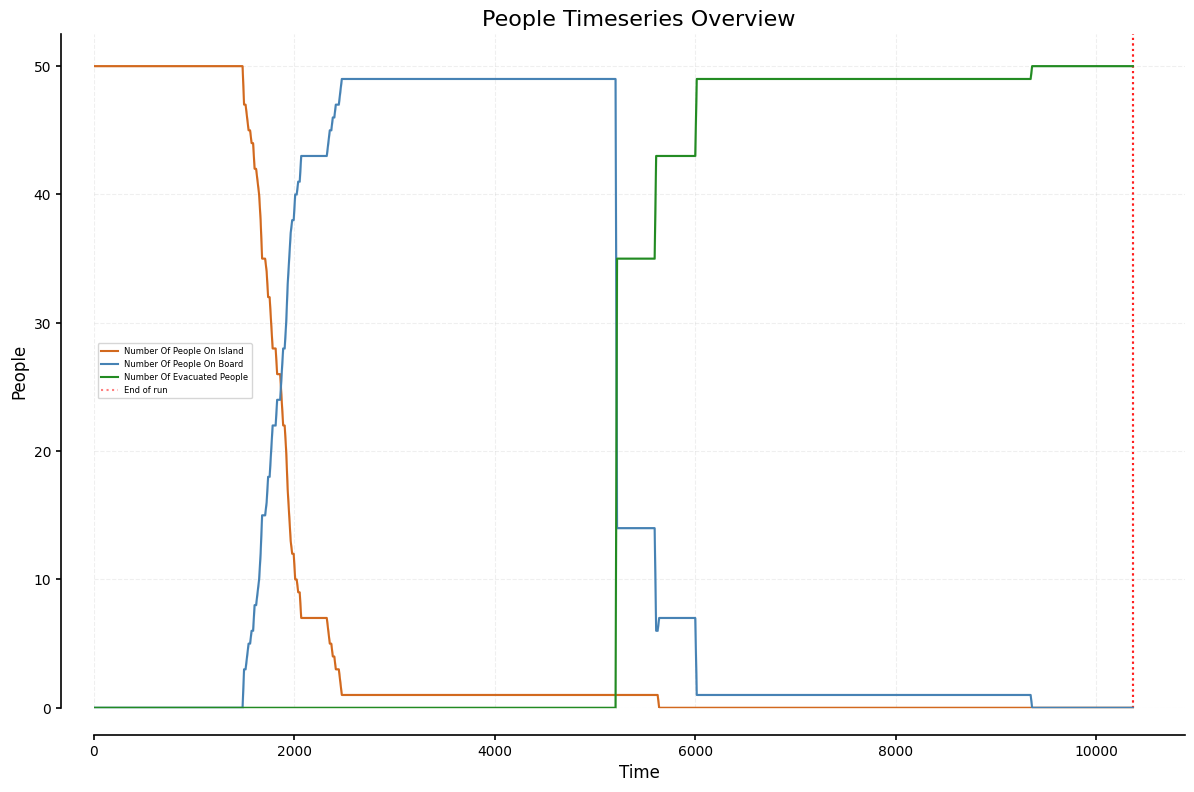

Plot not saved. Remember to set should_save to True if you want to save it.


In [ ]:
#multiple line plot
multiple_line_plots_dict = {
    'humans_overview': {
        'columns': ['nb_humans_on_island', 'nb_humans_on_board', 'nb_evacuated_humans'],
        'title': "Humans Timeseries Overview",
        'filename': "humans_timeseries_overview",
        'ylabel': "Humans",
    },
    'people_overview': {
        'columns': ['nb_people_on_island', 'nb_people_on_board', 'nb_evacuated_people'],
        'title': "People Timeseries Overview",
        'filename': "people_timeseries_overview",
        'ylabel': "People",
    },
    'LEAs_overview': {
        'columns': ['nb_LEAs_on_island', 'nb_LEAs_on_board', 'nb_evacuated_LEAs'],
        'title': "LEAs Timeseries Overview",
        'filename': "LEAs_timeseries_overview",
        'ylabel': "Law Enforcement Agents",
    },
    # 'emotional_overview': {
    #     'columns': ['nb_LEAs_on_island', 'nb_LEAs_on_board', 'nb_evacuated_LEAs'],
    #     'title': "Emotional Timeseries Overview",
    #     'filename': "emotion_timeseries_overview",
    #     'ylabel': "Law Enforcement Agents",
    # },
} 

selected_plot = 'people_overview'
make_it_fancy = True

plot_dict = multiple_line_plots_dict[selected_plot]

columns_to_plot = plot_dict['columns']

plot_df = temporal_df.groupby('time')[columns_to_plot].agg(['mean', 'std']).reset_index()
df_max_time = temporal_df.groupby('run_id')['time'].max()

plt.figure(figsize=(12, 8))

for column in columns_to_plot:
    plt.plot(plot_df['time'], plot_df[(column, 'mean')], color=series_color[column], label=f'{SERIES_NAME_MAPPING[column]}', zorder=3)
    plt.fill_between(
        plot_df['time'],
        plot_df[(column, 'mean')] - plot_df[(column, 'std')],
        plot_df[(column, 'mean')] + plot_df[(column, 'std')],
        color=series_color[column],
        alpha=0.2, 
        zorder=2,
    )

first_line = True
for run_id, max_time in df_max_time.items():
    if first_line:
        plt.axvline(x=max_time, color=end_of_run_color, linestyle=':', alpha = 0.5, label=f'End of run', zorder=1)
        first_line = False
    else:
        plt.axvline(x=max_time, color=end_of_run_color, linestyle=':', alpha = 0.5, zorder=1) 

plt.xlim(0, temporal_df['time'].max()*1.05)
plt.ylim(0)
plt.legend(fontsize=6)
plt.title(plot_dict['title'], fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel(plot_dict['ylabel'], fontsize=12)
plt.grid(True, linestyle='--', alpha=0.2)

if make_it_fancy:
    ax = plt.gca()
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.spines['bottom'].set_position(('axes', -0.04))
    ax.spines['left'].set_position(('axes', -0.03))
plt.tight_layout()

if make_it_fancy:
    plot_filename=plot_dict['filename'] + "_fancy.png"
else:
    plot_filename=plot_dict['filename'] + ".png"
plot_filepath=os.path.join(plot_dir, plot_filename)
saving_manager(should_save=False, save_path=plot_filepath, should_show=True)

In [ ]:
#saving_them_all

plot_filename= 
plot_filepath=
saving_manager(should_save=True, save_path=plot_filepath, should_show=False)

In [ ]:
#single line plot
columns_to_plot = [col for col in temporal_df.columns if col not in ['time', 'run_id']]

In [ ]:
#per le emozioni fai il rapporto tra il numero di persone che si sentono in quel modo e il numero di persone rimaste  